## 1 - Model 2 Random Forest

Based on evidence from recent studies, tree-based ensemble models such as  Random Forest seem the most suitable choice for intrusion detection using the NSL-KDD dataset. RF consistently achieved accuracy above 99% across multiple experiments (Abrar et al., 2020; Hegde et al., 2024; Hong et al., 2021; Gawand & Meesala, 2025). It effectively handles the dataset’s mixed-type features and class imbalance, while providing high interpretability and resilience to overfitting. Compared to deep learning models, RF offers an optimal trade-off between performance, computational efficiency and ease of implementation. This makes it a very appropriate algorithm for both academic experimentation and practical network intrusion detection.

Main goal is to:
* Identify the most informative NSL-KDD features
* Improve multi-class prediction performance over logistic regression
* Build a more expressive model without overfitting
* Evaluate Model 2, generate interpretable insights to produce a final, optimized RF model ready for test evaluation

Furthermore, in Model 2, the RF algorithm is intentionally used twice, but for two different purposes. First, an initial RF is trained on the full feature set to compute feature importances. This model is not used for prediction, it is only used to rank the NSL-KDD attributes and identify which features carry meaningful signal versus which ones introduce noise or redundancy. Based on this ranking, a reduced subset of the most informative features is selected. In the second stage, a new RF model is trained and only on the selected features, to serve as the actual predictive classifier. This separation ensures that the final model benefits from a cleaner and lower-dimensional feature space and enables an assessment of how feature selection influences model performance.



In [1]:
# Start by importing all required libs...
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
from utils import load_split, FEATURE_COLUMNS, make_binary_labels
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc, precision_recall_curve, roc_auc_score
import warnings
from sklearn.exceptions import UndefinedMetricWarning
import matplotlib.pyplot as plt
import joblib

%matplotlib inline
plt.style.use('./deeplearning.mplstyle')

In [2]:
# Part one: selecting the most important features
DATA_DIR   = Path("data/processed")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print("The shapes:")
print("  X_train:", X_train.shape)
print("  X_val:  ", X_val.shape)
print("  X_test: ", X_test.shape)

assert X_train.shape[1] == len(FEATURE_COLUMNS), "Feature dimension issue..."


# RF used only for ranking features
rf_feat_imp = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample", # minority classes are not ignored
)
rf_feat_imp.fit(X_train, y_train)

importances = rf_feat_imp.feature_importances_

feat_imp_df = (
    pd.DataFrame({"feature": FEATURE_COLUMNS, "importance": importances})
    .sort_values("importance", ascending=False)
)

print("\nTop 10 features by RF importance:")
print(feat_imp_df.head(10))

TOP_F = 20 # 50% dimensionality reduction
top_features = feat_imp_df.head(TOP_F)["feature"].tolist()
print(f"\nSelected top-{TOP_F} features:\n", top_features)

# create index mapping
name_to_idx = {name: idx for idx, name in enumerate(FEATURE_COLUMNS)}
selected_idx = [name_to_idx[f] for f in top_features]

X_train_sel = X_train[:, selected_idx]
X_val_sel   = X_val[:,   selected_idx]
X_test_sel  = X_test[:,  selected_idx]

print("\n The shapes after feature selection:")
print("  X_train_sel:", X_train_sel.shape)
print("  X_val_sel:  ", X_val_sel.shape)
print("  X_test_sel: ", X_test_sel.shape)

The shapes:
  X_train: (100778, 41)
  X_val:   (25195, 41)
  X_test:  (22544, 41)

Top 10 features by RF importance:
                        feature  importance
4                     src_bytes    0.116782
32           dst_host_srv_count    0.085779
5                     dst_bytes    0.072567
2                       service    0.071177
11                    logged_in    0.057366
23                    srv_count    0.043835
34       dst_host_diff_srv_rate    0.039332
37         dst_host_serror_rate    0.038756
35  dst_host_same_src_port_rate    0.037824
22                        count    0.037453

Selected top-20 features:
 ['src_bytes', 'dst_host_srv_count', 'dst_bytes', 'service', 'logged_in', 'srv_count', 'dst_host_diff_srv_rate', 'dst_host_serror_rate', 'dst_host_same_src_port_rate', 'count', 'duration', 'serror_rate', 'srv_serror_rate', 'dst_host_same_srv_rate', 'dst_host_count', 'dst_host_srv_diff_host_rate', 'root_shell', 'hot', 'protocol_type', 'dst_host_srv_serror_rate']

 The sh

In [12]:
# Create a baseline RF
rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_full.fit(X_train, y_train)

# label_map = {
#     "normal": "Normal",
#     "dos": "DoS",
#     "probe": "Probe",
#     "r2l": "R2L",
#     "u2r": "U2R",
# }

# # Load class labels from the encoder (created in data prep)
# y_encoder = joblib.load("data/processed/label_encoder.joblib")
# # class_names = y_encoder.classes_
# class_names = [label_map[c] for c in y_encoder.classes_]
# class_labels = list(range(len(class_names)))


# tick_marks = np.arange(len(class_names))


y_val_pred_full = rf_full.predict(X_val)

# # Confusion matrix
# cm_full = confusion_matrix(y_val, y_val_pred_full, labels=class_labels, normalize='true')

# classes = np.arange(cm_full.shape[0])

# plt.figure(figsize=(8, 6))
# plt.imshow(cm_full, interpolation='nearest', cmap="Blues")
# plt.title("Confusion Matrix – Random Forest (5 classes)")
# plt.colorbar()
# plt.xticks(tick_marks, class_names, rotation=90)
# plt.yticks(tick_marks, class_names)
# plt.xlabel("Predicted label")
# plt.ylabel("True label")
# plt.tight_layout()
# plt.show()



warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

print("Random Forest: all features")
print(classification_report(y_val, y_val_pred_full, digits=4)) # use 4 digits for more precise comparison?
print("Accuracy:", accuracy_score(y_val, y_val_pred_full))

# Evaluate full-feature model on the test set
y_test_pred_full = rf_full.predict(X_test)

print("Random Forest: all features (test set)")
print(classification_report(y_test, y_test_pred_full, digits=4))
print("Accuracy:", accuracy_score(y_test, y_test_pred_full))


Random Forest: all features
              precision    recall  f1-score   support

           0     0.9998    0.9999    0.9998      9186
           1     0.9980    0.9996    0.9988     13469
           2     0.9991    0.9931    0.9961      2331
           3     1.0000    0.9598    0.9795       199
           4     0.8889    0.8000    0.8421        10

    accuracy                         0.9987     25195
   macro avg     0.9772    0.9505    0.9633     25195
weighted avg     0.9987    0.9987    0.9987     25195

Accuracy: 0.9987299067275253
Random Forest: all features (test set)
              precision    recall  f1-score   support

           0     0.9601    0.7680    0.8534      7458
           1     0.6347    0.9726    0.7681      9711
           2     0.8608    0.5997    0.7069      2423
           3     0.7500    0.0010    0.0021      2885
           4     0.5000    0.0299    0.0563        67

    accuracy                         0.7377     22544
   macro avg     0.7411    0.4742  

During evaluation, scikit-learn generated ‘UndefinedMetricWarning’ for U2R and R2L classes. This occurs when the model predicts zero samples for a class, causing precision or F1-score to be undefined. This is typical for the NSL-KDD dataset, where some classes are extremely underrepresented.

The classification report for the Random Forest models shows that the five attack categories are strongly imbalanced, with U2R in particular having very low support (e.g., 10 samples in validation and 67 in the test set). While majority categories such as normal, DoS, and Probe contain thousands of samples and achieve very strong validation performance, the rare categories (especially U2R and, on the test set, R2L) are harder to evaluate reliably and exhibit substantially lower recall. This imbalance also explains why the macro-averaged scores are notably lower than the weighted averages: macro-averaging assigns equal weight to each category, so weak performance on rare categories reduces the overall macro metrics, whereas the weighted averages remain higher because they are dominated by the majority categories that the model classifies well. Overall, these observations primarily reflect structural properties of the NSL-KDD dataset and the distribution shift between training/validation and the test set, rather than a general failure of the Random Forest model.

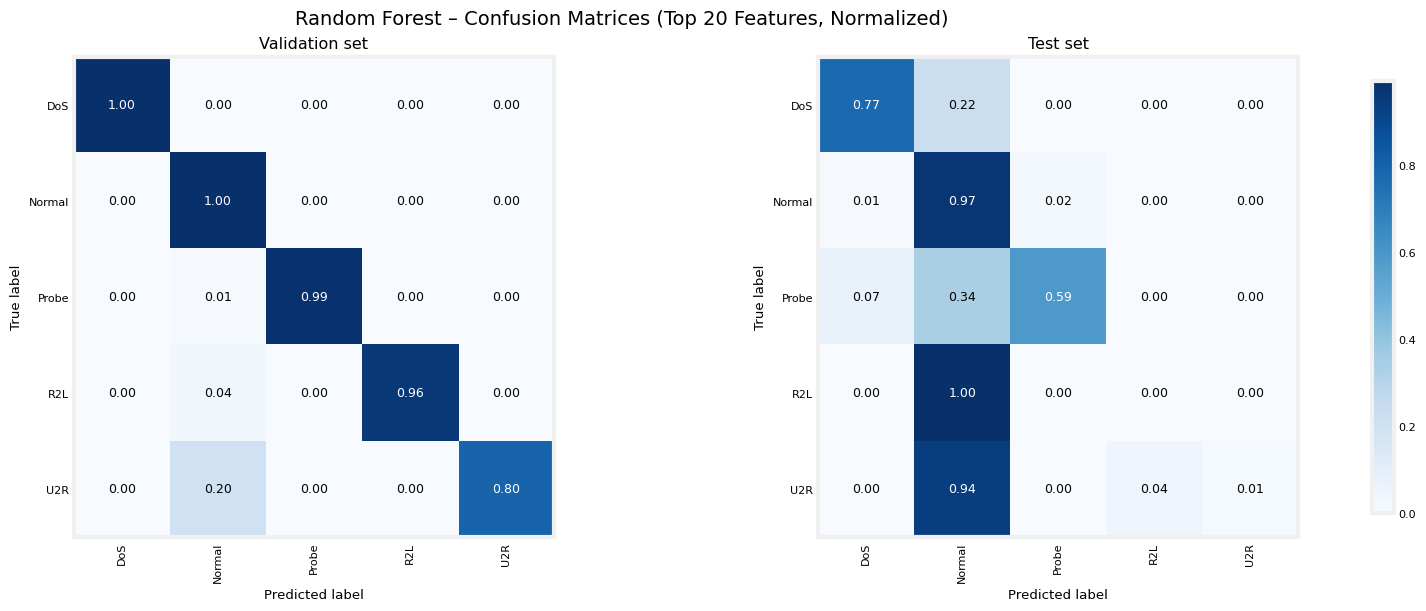

Random Forest: top 20 features
              precision    recall  f1-score   support

           0     0.9998    0.9999    0.9998      9186
           1     0.9978    0.9996    0.9987     13469
           2     0.9991    0.9914    0.9953      2331
           3     0.9948    0.9648    0.9796       199
           4     0.8889    0.8000    0.8421        10

    accuracy                         0.9986     25195
   macro avg     0.9761    0.9511    0.9631     25195
weighted avg     0.9986    0.9986    0.9986     25195

Accuracy: 0.998571145068466
Random Forest: top 20 features (test set)
              precision    recall  f1-score   support

           0     0.9567    0.7730    0.8551      7458
           1     0.6349    0.9700    0.7675      9711
           2     0.8573    0.5902    0.6991      2423
           3     0.7000    0.0024    0.0048      2885
           4     0.3333    0.0149    0.0286        67

    accuracy                         0.7374     22544
   macro avg     0.6964    0.4

In [ ]:
# RF with feature selection
rf_feat = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

rf_feat.fit(X_train_sel, y_train)

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

y_val_pred_sel = rf_feat.predict(X_val_sel)
y_test_pred_sel = rf_feat.predict(X_test_sel)


label_map = {
    "normal": "Normal",
    "dos": "DoS",
    "probe": "Probe",
    "r2l": "R2L",
    "u2r": "U2R",
}

# Load encoder and map to display names
y_encoder = joblib.load("data/processed/label_encoder.joblib")
class_names = [label_map[c] for c in y_encoder.classes_]
class_ids = np.arange(len(class_names))

# Row-normalized confusion matrices
cm_val = confusion_matrix(
    y_val, y_val_pred_sel,
    labels=class_ids,
    normalize="true"
)

cm_test = confusion_matrix(
    y_test, y_test_pred_sel,
    labels=class_ids,
    normalize="true"
)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for ax, cm, title in zip(
    axes,
    (cm_val, cm_test),
    ("Validation set", "Test set")
):
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title)

    ax.set_xticks(class_ids)
    ax.set_yticks(class_ids)
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]:.2f}",
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=9
            )

# Shared colorbar
fig.colorbar(im, ax=axes, shrink=0.9)
fig.suptitle(
    "Random Forest – Confusion Matrices (Top 20 Features, Normalized)",
    fontsize=14
)

plt.show()


print("Random Forest: top 20 features")
print(classification_report(y_val, y_val_pred_sel, digits=4))
print("Accuracy:", accuracy_score(y_val, y_val_pred_sel))

# Evaluate selected-feature model on the test set
y_test_pred_sel = rf_feat.predict(X_test_sel)

print("Random Forest: top 20 features (test set)")
print(classification_report(y_test, y_test_pred_sel, digits=4))
print("Accuracy:", accuracy_score(y_test, y_test_pred_sel))

Both Random Forest models, one trained on all 41 NSL-KDD features and one trained on the top-20 features selected using RF-based importance, achieve nearly identical performance. On the validation set, both models reach very high accuracy (≈0.999) and macro-averaged F1-scores around 0.96, with differences between the full-feature and reduced-feature models being negligible. When evaluated on the test set, both models experience a substantial and expected performance drop, achieving an accuracy of approximately 0.74 and a macro-F1 score of around 0.47. This decrease is a known characteristic of NSL-KDD, as the test set was intentionally designed by Tavallaee et al. (2009) to include attack patterns that differ from those seen during training, making generalization more challenging. Macro-F1 is further penalized by the extreme class imbalance of the dataset, as rare categories such as U2R and R2L contribute disproportionately to the unweighted average. 

To further examine model behavior, confusion matrices were generated for both the full-feature and selected-feature Random Forests. The confusion matrices confirm the quantitative evaluation: both Random Forest models exhibit almost identical behavior. For both models, the diagonal elements corresponding to the majority categories (normal, DoS, and Probe) remain very strong, demonstrating that Random Forests can reliably classify the dominant traffic classes. However, both confusion matrices also reveal a consistent drop in recall for rare categories, particularly U2R and (on the test set) R2L. In general, the full-feature model is at most marginally stronger, indicating that Random Forests already handle redundant or weak features effectively. Feature selection therefore does not provide a measurable performance gain in this setting, although it also does not significantly harm performance. These findings confirm that Random Forests are inherently robust to high-dimensional input, making explicit dimensionality reduction optional rather than necessary for the NSL-KDD dataset.

However, research suggests...




In the Logistic Regression baseline, both binary and multi-class formulations of the NSL-KDD task were evaluated, revealing a clear pattern: Logistic Regression performs extremely well in the binary normal-vs-attack setting but struggles in the multi-class scenario due to the strong skew toward rare categories. The Random Forest model exhibits a similar qualitative behavior: excellent performance on majority categories combined with notable difficulty on the long tail of infrequent attack categories, as reflected in the multi-class macro-F1 scores and confusion matrices. To enable a direct comparison with the Logistic Regression baseline and to isolate the true detection capability of the Random Forest model, the analysis is therefore extended with a binary classification experiment. This reduces the task to the fundamental intrusion-detection question of whether traffic is benign or malicious. The binary Random Forest results serve as an upper-bound estimate of detection performance and help clarify whether the observed multi-class limitations stem from model capacity or from structural properties of the dataset itself. Furthermore, Random Forests were not evaluated using ROC, AUC, or k-fold cross-validation, as in the binary setting the model already achieves near-perfect performance on the validation split, and such analyses would provide limited additional insight beyond confirming the same conclusion.

Normal class:  1
Binary RF (Validation) – Top 20 features
              precision    recall  f1-score   support

           0     0.9981    0.9994    0.9987     13469
           1     0.9993    0.9978    0.9985     11726

    accuracy                         0.9987     25195
   macro avg     0.9987    0.9986    0.9986     25195
weighted avg     0.9987    0.9987    0.9987     25195

Accuracy: 0.9986505258979956
Binary RF (Test) – Top 20 features
              precision    recall  f1-score   support

           0     0.6427    0.9708    0.7734      9711
           1     0.9639    0.5917    0.7333     12833

    accuracy                         0.7550     22544
   macro avg     0.8033    0.7812    0.7533     22544
weighted avg     0.8256    0.7550    0.7506     22544

Accuracy: 0.7549680624556423


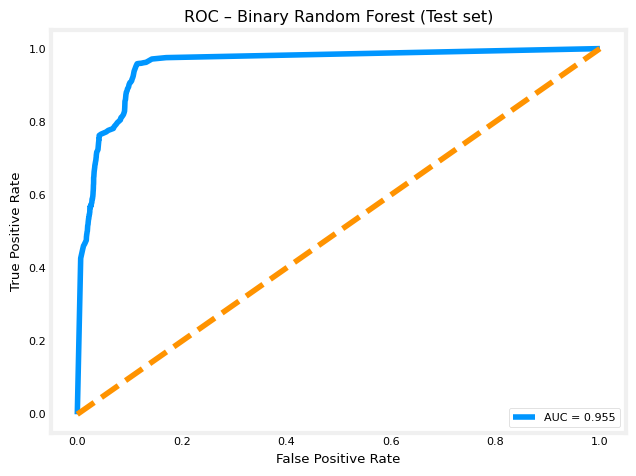

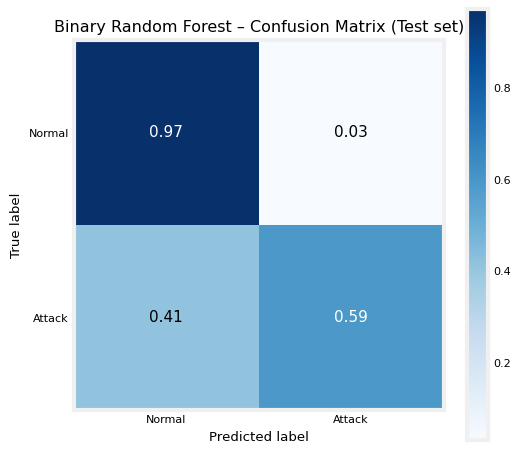

In [6]:
# Extract normal class and convert to binary labels
classes = y_encoder.classes_
normal_id = np.where(classes == "normal")[0][0]
print("Normal class: ", normal_id)

# y_train_bin = (y_train != normal_id).astype(int)
# y_val_bin   = (y_val   != normal_id).astype(int)
# y_test_bin  = (y_test  != normal_id).astype(int)
y_train_bin = make_binary_labels(y_train, normal_id)
y_val_bin   = make_binary_labels(y_val,   normal_id)
y_test_bin  = make_binary_labels(y_test,  normal_id)

# train and evaluate the binary model
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

rf_bin = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_bin.fit(X_train_sel, y_train_bin)

y_val_bin_pred = rf_bin.predict(X_val_sel)
print("Binary RF (Validation) – Top 20 features")
print(classification_report(y_val_bin, y_val_bin_pred, digits=4))
print("Accuracy:", accuracy_score(y_val_bin, y_val_bin_pred))

y_test_bin_pred = rf_bin.predict(X_test_sel)
print("Binary RF (Test) – Top 20 features")
print(classification_report(y_test_bin, y_test_bin_pred, digits=4))
print("Accuracy:", accuracy_score(y_test_bin, y_test_bin_pred))


# ROC

y_test_scores = rf_bin.predict_proba(X_test_sel)[:, 1]

fpr, tpr, _ = roc_curve(y_test_bin, y_test_scores)
auc = roc_auc_score(y_test_bin, y_test_scores)

plt.figure(figsize=(6.4, 4.8))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.title("ROC – Binary Random Forest (Test set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend([f"AUC = {auc:.3f}"], loc="lower right")
plt.tight_layout()
plt.show()

# confusion matrix
cm_bin = confusion_matrix(
    y_test_bin,
    y_test_bin_pred,
    normalize="true"
)

labels = ["Normal", "Attack"]

plt.figure(figsize=(5.5, 4.8))
plt.imshow(cm_bin, interpolation="nearest", cmap="Blues")
plt.title("Binary Random Forest – Confusion Matrix (Test set)")
plt.colorbar()

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")

# Add values inside cells
thresh = cm_bin.max() / 2
for i in range(cm_bin.shape[0]):
    for j in range(cm_bin.shape[1]):
        plt.text(
            j, i,
            f"{cm_bin[i, j]:.2f}",
            ha="center", va="center",
            color="white" if cm_bin[i, j] > thresh else "black",
            fontsize=11
        )

plt.tight_layout()
plt.show()

The binary classification experiment provides more insight into the Random Forest model’s true detection capability. On the validation set, the binary RF model achieves near-perfect performance (accuracy ≈ 0.999, F1 ≈ 0.999 for both classes). This demonstrates that, when the task is simplified to distinguishing benign vs. malicious traffic, the model performs exceptionally well and has no difficulty detecting attack activity in general. However, the behavior on the test set reveals an important aspect of the NSL-KDD benchmark. Although the binary accuracy remains substantial (≈ 0.755), the model shows a pronounced asymmetry between the two classes:
* Normal traffic: high recall (0.9708), but relatively low precision (0.6427), indicating that a non-trivial number of attack samples are incorrectly predicted as normal (false negatives) and that predicted “normal” labels include many missed attacks.
* Attack traffic: very high precision (0.9639), but low recall (0.5917), meaning that many attacks are missed rather than being incorrectly flagged as attacks.

This pattern indicates that the model becomes more conservative on unseen test data: it makes relatively few false attack predictions (high attack precision), but it fails to correctly identify a substantial fraction of test-set attacks (lower attack recall). This is consistent with the design of NSL-KDD: the test set contains attack patterns that differ from those seen during training, and some occur only rarely. As a result, even the binary classifier struggles to generalize to unfamiliar malicious behavior. Hence, the main difficulty in NSL-KDD is not learning to separate “normal vs attack” on the training distribution, but generalizing to rare or distribution-shifted attack patterns. This also helps explain why multi-class performance degrades on the test set: the model does not learn sufficiently robust decision rules for minority categories, and these weaknesses remain visible even in the binary setting when evaluated on the more challenging test split.

Finally, a neural-network model is included as a third approach. Although neural networks are not always necessary or consistently superior to classical machine-learning techniques on intrusion-detection datasets (Rawat et al., 2019; Ali et al., 2025), their capacity to model higher-order feature interactions makes them a useful point of comparison. Evaluating a neural-network architecture allows us to assess whether deeper non-linear representations provide additional benefits beyond those obtained with feature selection and tree-based models, ensuring a comprehensive comparison across linear and non-linear modeling strategies on the NSL-KDD dataset.